# Spectral Kernel Models — A Visual Guide for Earth-System Priors

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/spectral_kernel_models.ipynb)

This notebook is a **visual survey** of stationary spectral kernels — the building blocks behind every Bayesian-spectral layer in `pyrox.nn`. The companion [Kernel Approximation notebook](kernel_approximation.ipynb) pins down *why* random Fourier features approximate a kernel; here we step back and ask *which* kernel we should approximate in the first place, with a particular focus on **physically-motivated priors for ocean / land / atmosphere data**.

Three things you will see, all by drawing samples from the prior — no inference, no fitting:

1. **The zoo.** Side-by-side 1D and 2D realisations of RBF, Matérn-1/2 (Laplace), Matérn-3/2, Matérn-5/2, and the non-stationary ArcCosine [^chosaul2009] kernel. Same lengthscale, same seed family. Differences in *regularity*, *tail content*, and *stationarity* become immediately legible.
2. **A practical decision table.** When does each kernel make physical sense, and when does it fail? Five rows, four axes, one paragraph each.
3. **Three earth-system worked examples.** A representative kernel choice for each of ocean (SSH-like), land (precipitation-like), and atmosphere (synoptic-temperature-like) signals, with sample paths and 2D fields to ground the recommendation.

Cross-references throughout point to the literature; numbered footnotes collect full citations at the end.

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyrox[colab] @ git+https://github.com/jejjohnson/pyrox@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
from numpyro import handlers

from pyrox.nn import (
    ArcCosineFourierFeatures,
    LaplaceFourierFeatures,
    MaternFourierFeatures,
    RBFFourierFeatures,
)


jax.config.update("jax_enable_x64", True)

**Helpers.** All sample paths in this notebook follow the same recipe:

1. Build a `pyrox.nn` spectral layer with $M$ frequencies on a fixed lengthscale.
2. Trace it under `numpyro.handlers.seed` to materialise a single $\Omega$ draw.
3. Combine it linearly with $\beta \sim \mathcal{N}(0, I)$ — that gives a **GP prior sample** $f(x) = \beta^\top \phi(x)$ whose covariance is the Monte-Carlo Bochner kernel of the layer.

Vectorising the $\beta$ draw over a leading axis gives independent path samples. Fixed lengthscale across kernels keeps the comparison purely about regularity and tail behaviour.

In [3]:
def trace_features(layer, x, *, seed, lengthscale):
    """Materialise the random feature map at ``x``.

    Uses ``handlers.substitute`` to pin the lengthscale (the layers
    treat it as a prior site) so each kernel is compared at the *same*
    correlation length.
    """
    name = f"{layer.pyrox_name}.lengthscale"
    with (
        handlers.substitute(data={name: jnp.asarray(lengthscale)}),
        handlers.seed(rng_seed=seed),
    ):
        return layer(x)


def gp_paths_from_layer(layer, x, *, lengthscale, seed_omega, seed_beta, n_paths):
    """Draw ``n_paths`` independent GP prior samples through the feature map.

    ``f_s(x) = β_s^⊤ φ(x)`` with ``β_s ~ N(0, I)``. The Monte-Carlo
    covariance is the Bochner kernel of the layer's spectral density.
    """
    phi = trace_features(layer, x, seed=seed_omega, lengthscale=lengthscale)
    beta = jr.normal(jr.PRNGKey(seed_beta), (n_paths, phi.shape[-1]))
    return beta @ phi.T


def named(layer, name):
    """Convenience: rename a layer's ``pyrox_name`` (immutable update)."""
    return eqx.tree_at(lambda r: r.pyrox_name, layer, name)


def make_layer(kernel, in_features, *, n_features, lengthscale):
    """Construct a paired-RFF / ArcCosine layer by short string name."""
    if kernel == "RBF":
        return named(
            RBFFourierFeatures.init(
                in_features=in_features, n_features=n_features, lengthscale=lengthscale
            ),
            f"rbf_{in_features}d",
        )
    if kernel == "Matérn-1/2":
        return named(
            LaplaceFourierFeatures.init(
                in_features=in_features, n_features=n_features, lengthscale=lengthscale
            ),
            f"m12_{in_features}d",
        )
    if kernel == "Matérn-3/2":
        return named(
            MaternFourierFeatures.init(
                in_features=in_features,
                n_features=n_features,
                nu=1.5,
                lengthscale=lengthscale,
            ),
            f"m32_{in_features}d",
        )
    if kernel == "Matérn-5/2":
        return named(
            MaternFourierFeatures.init(
                in_features=in_features,
                n_features=n_features,
                nu=2.5,
                lengthscale=lengthscale,
            ),
            f"m52_{in_features}d",
        )
    if kernel == "ArcCosine-1":
        return named(
            ArcCosineFourierFeatures.init(
                in_features=in_features,
                n_features=n_features,
                order=1,
                lengthscale=lengthscale,
            ),
            f"arc_{in_features}d",
        )
    raise ValueError(f"Unknown kernel: {kernel}")

## 1. The spectral-kernel zoo

Five kernels, all on the same 1D grid, same lengthscale, same number of features. Three sample paths per kernel.

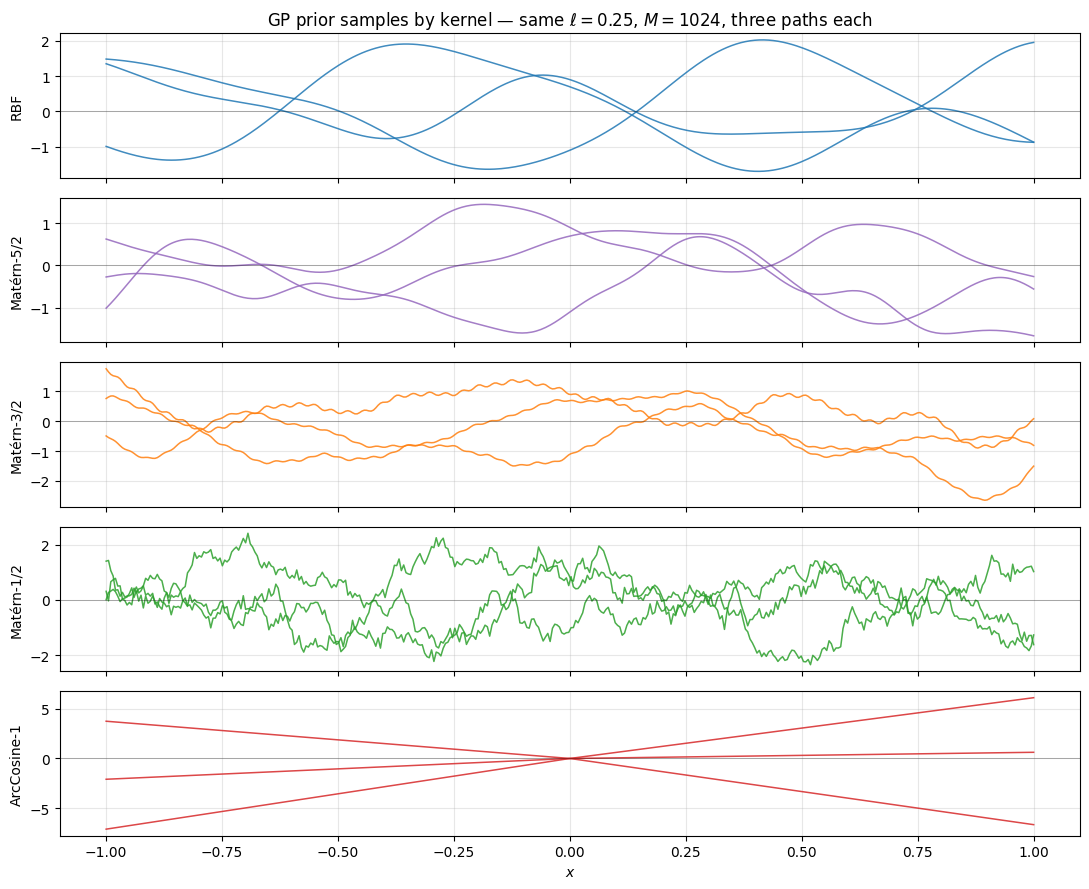

In [4]:
KERNELS = ["RBF", "Matérn-5/2", "Matérn-3/2", "Matérn-1/2", "ArcCosine-1"]
KERNEL_COLORS = {
    "RBF": "C0",
    "Matérn-5/2": "C4",
    "Matérn-3/2": "C1",
    "Matérn-1/2": "C2",
    "ArcCosine-1": "C3",
}
LENGTHSCALE_ZOO = 0.25
M_ZOO = 1024
N_PATHS = 3
x1 = jnp.linspace(-1.0, 1.0, 400).reshape(-1, 1)

paths_1d = {}
for kernel in KERNELS:
    layer = make_layer(
        kernel, in_features=1, n_features=M_ZOO, lengthscale=LENGTHSCALE_ZOO
    )
    paths_1d[kernel] = gp_paths_from_layer(
        layer,
        x1,
        lengthscale=LENGTHSCALE_ZOO,
        seed_omega=0,
        seed_beta=10,
        n_paths=N_PATHS,
    )

fig, axes = plt.subplots(len(KERNELS), 1, figsize=(11, 9), sharex=True)
for ax, kernel in zip(axes, KERNELS, strict=False):
    color = KERNEL_COLORS[kernel]
    for s in range(N_PATHS):
        ax.plot(x1[:, 0], paths_1d[kernel][s], color=color, alpha=0.85, linewidth=1.1)
    ax.set_ylabel(kernel, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(0.0, color="k", linewidth=0.5, alpha=0.4)
axes[0].set_title(
    f"GP prior samples by kernel — same $\\ell = {LENGTHSCALE_ZOO}$, $M = {M_ZOO}$, three paths each"
)
axes[-1].set_xlabel("$x$")
plt.tight_layout()
plt.show()

Walking down the figure: **RBF** and **Matérn-5/2** are visually almost indistinguishable — both are smooth enough that mean-square derivatives of every order (RBF) or up to order 2 (Matérn-5/2) exist. **Matérn-3/2** has visible kinks (one m.s. derivative). **Matérn-1/2** (Laplace, equivalently the Ornstein-Uhlenbeck process) is continuous but nowhere differentiable — pure jagged texture. **ArcCosine-1**, by contrast, is *not stationary*: the ReLU-rectified random projections produce piecewise-affine sample paths whose roughness changes across $x$ — a fundamentally different prior, useful when the field has localised abrupt transitions [^chosaul2009].

### 1.1 Empirical Gram and spectral density

Two more views of the same five kernels. The Gram matrix shows correlation structure as $\|x - x'\|$ grows. The spectral density $p(\omega)$ — what the random Fourier features actually sample from — is what makes the differences *predictable*: heavy-tailed densities admit high-frequency content and produce rougher fields; light-tailed densities band-limit the signal.

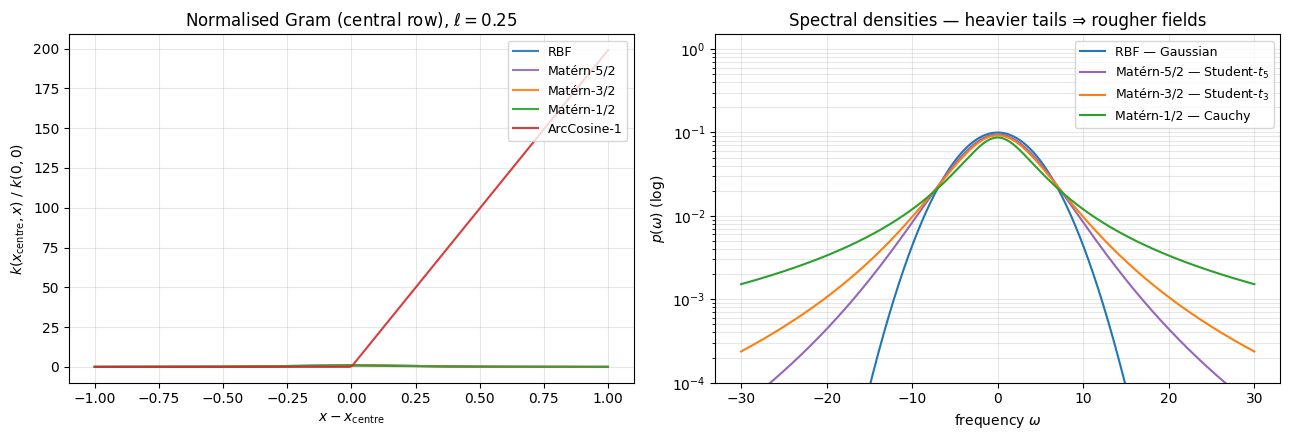

In [5]:
n_grid_g = 200
xg = jnp.linspace(-1.0, 1.0, n_grid_g).reshape(-1, 1)
i_centre = n_grid_g // 2

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Empirical central-row Gram from the same M=1024 features.
ax = axes[0]
for kernel in KERNELS:
    layer = make_layer(
        kernel, in_features=1, n_features=M_ZOO, lengthscale=LENGTHSCALE_ZOO
    )
    phi = trace_features(layer, xg, seed=0, lengthscale=LENGTHSCALE_ZOO)
    K = phi @ phi.T
    K = K / float(K[i_centre, i_centre])  # normalise to k(0) = 1
    ax.plot(
        xg[:, 0],
        K[i_centre],
        color=KERNEL_COLORS[kernel],
        linewidth=1.5,
        label=kernel,
        alpha=0.9,
    )
ax.set_xlabel(r"$x - x_{\mathrm{centre}}$")
ax.set_ylabel(r"$k(x_{\mathrm{centre}}, x)\ /\ k(0, 0)$")
ax.set_title(f"Normalised Gram (central row), $\\ell = {LENGTHSCALE_ZOO}$")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc="upper right")

# Analytic spectral densities for the stationary kernels.
# Each plotted with lengthscale ℓ baked in: the effective frequency is ω/ℓ
# in pyrox layers, so on physical-frequency axes the density narrows as ℓ grows.
ax = axes[1]
omega = np.linspace(-30.0, 30.0, 800)
ell = LENGTHSCALE_ZOO

# RBF spectrum: N(0, ℓ^-2)
p_rbf = (ell / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * (ell * omega) ** 2)


# Matern-ν spectrum (1D): proportional to (1 + (ℓω)^2 / 2ν)^(-(ν + 1/2))
def matern_spectrum(omega, ell, nu):
    z = (ell * omega) ** 2 / (2.0 * nu)
    pdf = (1.0 + z) ** (-(nu + 0.5))
    return pdf / np.trapezoid(pdf, omega)


p_m12 = matern_spectrum(omega, ell, nu=0.5)
p_m32 = matern_spectrum(omega, ell, nu=1.5)
p_m52 = matern_spectrum(omega, ell, nu=2.5)

ax.plot(omega, p_rbf, color=KERNEL_COLORS["RBF"], label="RBF — Gaussian")
ax.plot(
    omega, p_m52, color=KERNEL_COLORS["Matérn-5/2"], label=r"Matérn-5/2 — Student-$t_5$"
)
ax.plot(
    omega, p_m32, color=KERNEL_COLORS["Matérn-3/2"], label=r"Matérn-3/2 — Student-$t_3$"
)
ax.plot(omega, p_m12, color=KERNEL_COLORS["Matérn-1/2"], label="Matérn-1/2 — Cauchy")
ax.set_yscale("log")
ax.set_ylim(1e-4, 1.5)
ax.set_xlabel(r"frequency $\omega$")
ax.set_ylabel(r"$p(\omega)$ (log)")
ax.set_title("Spectral densities — heavier tails ⇒ rougher fields")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.show()

ArcCosine has no Bochner spectral density (it is not shift-invariant), so it is omitted from the right panel. For the four stationary kernels the right panel tells the whole story: the **Cauchy spectrum** of Matérn-1/2 falls off as $\omega^{-2}$ — heavy enough that all polynomial moments diverge, hence sample paths are continuous but nowhere differentiable. **RBF**'s Gaussian spectrum drops super-exponentially — sample paths are $C^\infty$. Matérn-3/2 and 5/2 sit in between (Student-$t_3$ / $t_5$), giving exactly $\nu - \tfrac12$ Hölder regularity. This is *the* qualitative knob for kernel selection.

### 1.2 The same kernels in 2D

Same lengthscale, same kernels, samples on a 2D grid. The 2D view is what one usually wants for spatial fields (maps).

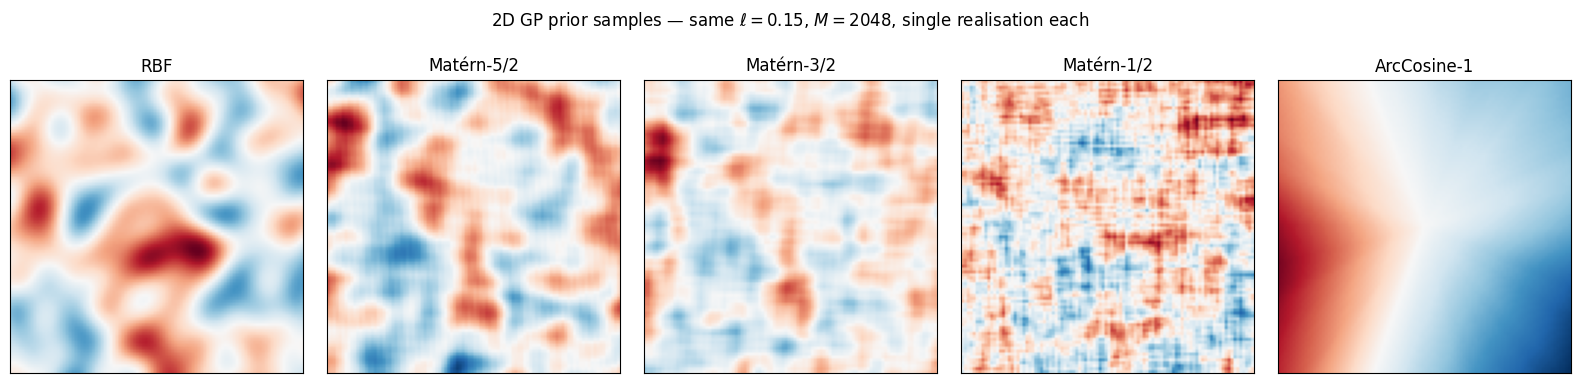

In [6]:
n_grid_2d = 100
LENGTHSCALE_2D = 0.15
M_2D = 2048
xs = jnp.linspace(-1.0, 1.0, n_grid_2d)
X, Y = jnp.meshgrid(xs, xs, indexing="xy")
x2 = jnp.stack([X.flatten(), Y.flatten()], axis=-1)

fields_2d = {}
for kernel in KERNELS:
    layer = make_layer(
        kernel, in_features=2, n_features=M_2D, lengthscale=LENGTHSCALE_2D
    )
    paths = gp_paths_from_layer(
        layer, x2, lengthscale=LENGTHSCALE_2D, seed_omega=7, seed_beta=20, n_paths=1
    )
    fields_2d[kernel] = np.asarray(paths[0]).reshape(n_grid_2d, n_grid_2d)

fig, axes = plt.subplots(1, len(KERNELS), figsize=(16, 3.6))
for ax, kernel in zip(axes, KERNELS, strict=False):
    field = fields_2d[kernel]
    vmax = float(np.abs(field).max())
    ax.imshow(
        field,
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
        origin="lower",
        extent=(-1, 1, -1, 1),
    )
    ax.set_title(kernel)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle(
    f"2D GP prior samples — same $\\ell = {LENGTHSCALE_2D}$, $M = {M_2D}$, single realisation each",
    y=1.05,
)
plt.tight_layout()
plt.show()

In 2D the regularity story is even more obvious. RBF and Matérn-5/2 give smooth, ridge-and-trough patterns. Matérn-3/2 retains the same coherence but with sharper detail. Matérn-1/2 is salt-and-pepper at the small scale yet still globally correlated — the right prior when fronts and discontinuities are real. ArcCosine produces blocky, hyperplane-bounded regions characteristic of ReLU networks.

## 2. Why use one over another — a decision table

Four practical axes on a single line each.

| Kernel | Path regularity | Spectrum tail | Stationary? | Use when… |
|---|---|---|---|---|
| **RBF** | $C^\infty$ — analytical | super-exponential (Gaussian) | yes | the field is genuinely smooth and bandlimited (laboratory data, idealised PDEs) |
| **Matérn-5/2** | 2 m.s. derivatives | Student-$t_5$ | yes | "smooth-ish" geophysical fields where you don't trust $C^\infty$ — synoptic atmosphere, large-scale SST [^stein1999][^williamsrasmussen2006] |
| **Matérn-3/2** | 1 m.s. derivative | Student-$t_3$ | yes | the default geostatistics workhorse — mesoscale ocean, soil properties, kriging [^stein1999] |
| **Matérn-1/2 (Laplace)** | continuous, nowhere diff. | Cauchy | yes | rough / mean-reverting fields — turbulence, precipitation, ocean colour patches [^cressiewikle2011] |
| **ArcCosine-1** | piecewise-affine | n/a (non-stationary) | **no** | localised abrupt transitions, learned representations, function classes that benefit from ReLU-NN structure [^chosaul2009] |

**Quick rules of thumb.**

- **Don't reach for RBF by default.** Stein 1999 [^stein1999] §2.7 makes the now-standard argument: real geophysical fields are almost never $C^\infty$, and Matérn-3/2 or 5/2 is usually a better default. The classic worry is that RBF over-confidently extrapolates because its prior bandwidth is genuinely tiny.
- **Pick $\nu$ based on physical regularity.** Quasi-geostrophic flows admit two-three derivatives → $\nu \in \{1.5, 2.5\}$. Turbulent / intermittent fields → $\nu = 0.5$.
- **Heavy spectral tails ⇒ rough samples.** If you suspect the data spectrum decays as $|\omega|^{-\alpha}$ for small $\alpha$, choose Matérn-$\nu$ with $\nu \approx (\alpha - d) / 2$ — that matches the asymptotic spectrum [^stein1999].
- **ArcCosine and friends are for non-stationary structure.** If you need amplitude / wavelength to depend on $x$ (e.g., bathymetry-dependent SSH variance, orographic precipitation), a stationary Matérn is wrong; reach for ArcCosine, deep RFFs [Cutajar et al. 2017](deep_random_fourier_features.ipynb), or the spectral-mixture kernels of Wilson & Adams [^wilsonadams2013].

## 3. Physics-informed priors for the Earth system

A pocket reference for kernel choices in three Earth-system tiers. Each table cell is a **prior recommendation** — what the data tend to look like when you sample from a candidate prior — *not* a fitted result.

### Ocean

| Variable | Kernel | Why | Refs |
|---|---|---|---|
| SSH (sea surface height, mesoscale eddies) | Matérn-3/2 (anisotropic) | known mesoscale length scales (~50–100 km); turbulent cascade slope $\sim k^{-2}$ to $k^{-3}$ in the inertial range | [^ubelmann2014][^letraon2003] |
| SST (sea surface temperature) | Matérn-3/2 to 5/2 | thermal smoothing dominates; submesoscale fronts add roughness | [^banzon2016] |
| SSS (sea surface salinity) | Matérn-3/2 | river-plume / mixing fronts; intermediate regularity | [^reul2020] |
| Ocean colour (chl-a, CDOM) | Matérn-1/2 + log transform | patchy, intermittent, log-normal in amplitude | [^doney2007] |

**Demo: an SSH-flavoured field.** A Matérn-3/2 prior on a 2D patch with anisotropic lengthscales (longer in zonal direction) — what mesoscale eddy fields on a satellite altimetry track look like before any data lands.

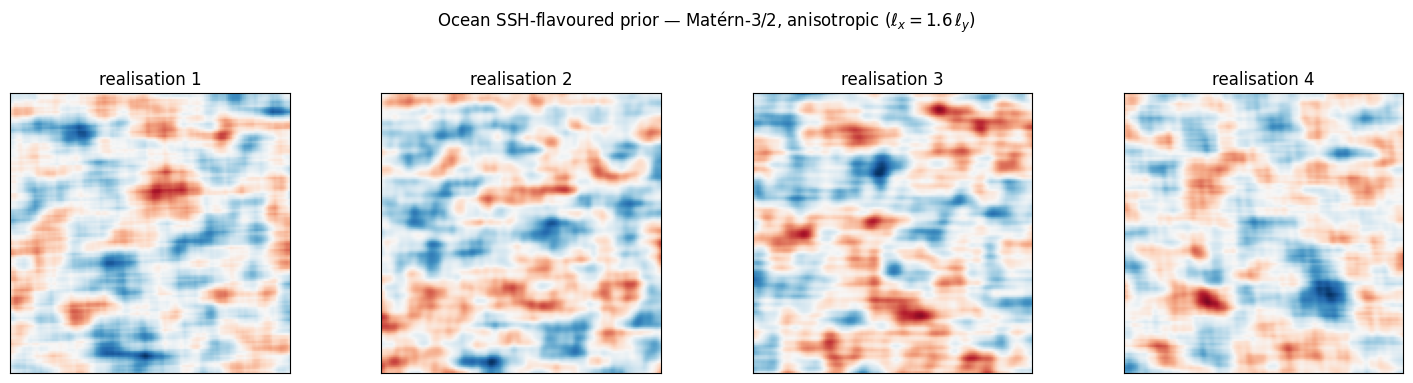

In [7]:
LENGTHSCALE_OCEAN = 0.10
M_OCEAN = 2048
n_grid_ocean = 140
xs_o = jnp.linspace(-1.0, 1.0, n_grid_ocean)
Xo, Yo = jnp.meshgrid(xs_o, xs_o, indexing="xy")
# Anisotropy: stretch x by 1.6× to mimic zonal alignment of mesoscale eddies.
x2_ocean = jnp.stack([Xo.flatten() / 1.6, Yo.flatten()], axis=-1)
ocean_layer = make_layer(
    "Matérn-3/2", in_features=2, n_features=M_OCEAN, lengthscale=LENGTHSCALE_OCEAN
)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
ssh_truth = None
for ax, seed in zip(axes, [0, 1, 2, 3], strict=False):
    paths = gp_paths_from_layer(
        ocean_layer,
        x2_ocean,
        lengthscale=LENGTHSCALE_OCEAN,
        seed_omega=seed,
        seed_beta=100 + seed,
        n_paths=1,
    )
    field = np.asarray(paths[0]).reshape(n_grid_ocean, n_grid_ocean)
    if seed == 0:
        ssh_truth = field
    vmax = float(np.abs(field).max())
    im = ax.imshow(
        field,
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
        origin="lower",
        extent=(-1, 1, -1, 1),
    )
    ax.set_title(f"realisation {seed + 1}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle(
    "Ocean SSH-flavoured prior — Matérn-3/2, anisotropic ($\\ell_x = 1.6\\,\\ell_y$)",
    y=1.05,
)
plt.tight_layout()
plt.show()

Eddy-shaped highs and lows of the right qualitative size, anisotropy aligned with $x$. A Matérn-1/2 prior in the same setting would give salt-and-pepper noise; an RBF prior would give over-smooth blobs without sharp eddy edges. Matérn-3/2 is the consensus altimetry choice [^ubelmann2014].

**More ocean variables — SST, SSS, ocean colour.** Three more 2D priors at qualitatively different smoothness levels. Each panel uses the kernel and lengthscale recommended in the table: Matérn-5/2 (long $\ell$) for SST's broad thermal patches, Matérn-3/2 (medium $\ell$) for SSS where river-plume / mixing fronts add sharper structure, and Matérn-1/2 (short $\ell$) followed by a log-normal transform for ocean-colour patchiness.

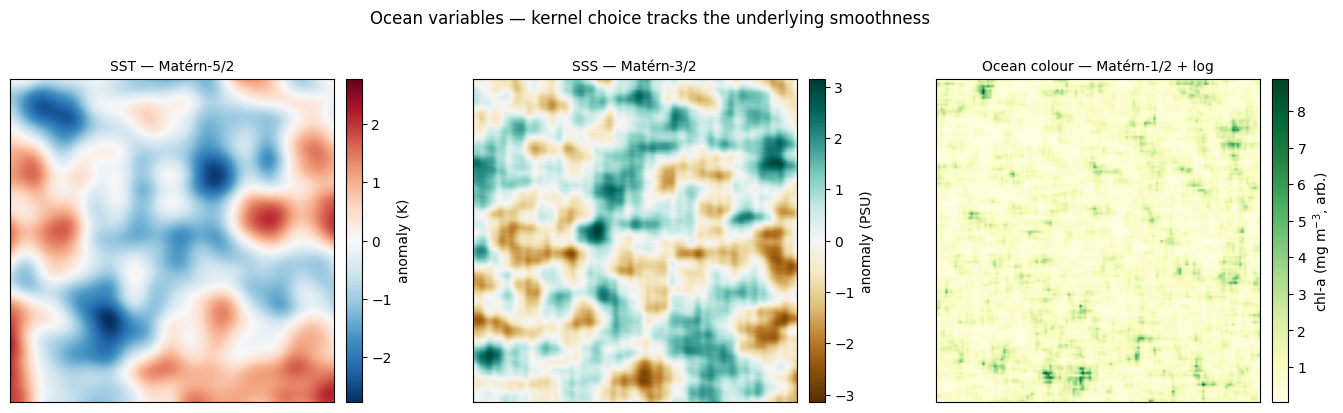

In [8]:
n_grid_oc = 140
xs_oc = jnp.linspace(-1.0, 1.0, n_grid_oc)
Xoc, Yoc = jnp.meshgrid(xs_oc, xs_oc, indexing="xy")
x2_oc = jnp.stack([Xoc.flatten(), Yoc.flatten()], axis=-1)

ocean_demos = [
    {
        "title": "SST — Matérn-5/2",
        "kernel": "Matérn-5/2",
        "lengthscale": 0.22,
        "seed_omega": 11,
        "seed_beta": 411,
        "transform": None,
        "cmap": "RdBu_r",
        "label": "anomaly (K)",
    },
    {
        "title": "SSS — Matérn-3/2",
        "kernel": "Matérn-3/2",
        "lengthscale": 0.13,
        "seed_omega": 12,
        "seed_beta": 412,
        "transform": None,
        # BrBG: brown for low (fresh) → blue-green for high (saline) —
        # the cmocean.haline-style convention for salinity contrast.
        "cmap": "BrBG",
        "label": "anomaly (PSU)",
    },
    {
        "title": "Ocean colour — Matérn-1/2 + log",
        "kernel": "Matérn-1/2",
        "lengthscale": 0.06,
        "seed_omega": 13,
        "seed_beta": 413,
        # Log-normal-style transform: chl-a ≈ exp(σ f − σ²/2) keeps the field
        # positive and heavy-tailed, mimicking the well-known log-normal
        # distribution of chlorophyll concentrations in the open ocean.
        "transform": lambda f: np.exp(0.7 * f - 0.5 * 0.7**2),
        # YlGn: pale yellow → deep green — the conventional chlorophyll
        # palette (cmocean.algae-style without the dependency).
        "cmap": "YlGn",
        "label": r"chl-a (mg m$^{-3}$, arb.)",
    },
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.0))
for ax, spec in zip(axes, ocean_demos, strict=False):
    layer = make_layer(
        spec["kernel"],
        in_features=2,
        n_features=M_OCEAN,
        lengthscale=spec["lengthscale"],
    )
    paths = gp_paths_from_layer(
        layer,
        x2_oc,
        lengthscale=spec["lengthscale"],
        seed_omega=spec["seed_omega"],
        seed_beta=spec["seed_beta"],
        n_paths=1,
    )
    field = np.asarray(paths[0]).reshape(n_grid_oc, n_grid_oc)
    if spec["transform"] is not None:
        field = spec["transform"](field)
        im = ax.imshow(field, cmap=spec["cmap"], origin="lower", extent=(-1, 1, -1, 1))
    else:
        vmax = float(np.abs(field).max())
        im = ax.imshow(
            field,
            cmap=spec["cmap"],
            vmin=-vmax,
            vmax=vmax,
            origin="lower",
            extent=(-1, 1, -1, 1),
        )
    ax.set_title(spec["title"], fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03, label=spec["label"])
plt.suptitle("Ocean variables — kernel choice tracks the underlying smoothness", y=1.02)
plt.tight_layout()
plt.show()

Reading the panels left-to-right: SST shows broad warm/cool anomalies, the kind of thermal structure one would see in a monthly anomaly map; SSS has tighter fronts where freshwater plumes / shelf-break mixing intersect; ocean colour, after the log transform, becomes a positive heavy-tailed field with isolated high-concentration patches surrounded by low-chlorophyll background — the qualitative signature of bloom and oligotrophic regions [^doney2007][^reul2020][^banzon2016]. Without the transform, ocean colour drawn directly from a Gaussian prior would be physically meaningless (negative concentrations).

### Land

| Variable | Kernel | Why | Refs |
|---|---|---|---|
| Air temperature | Matérn-5/2 | smooth, large coherence length (~100s of km) | [^hengl2018] |
| Soil moisture | Matérn-3/2 | mixed boundary-layer + subsurface processes | [^vereecken2008] |
| Precipitation | Matérn-1/2 + log transform | intermittent, heavy-tailed, on/off [^cressiewikle2011] | [^sun2018] |
| Wind / orographic | Matérn-3/2 + nonstationarity | direction- and elevation-dependent | [^gneiting2002] |

**Demo: a precipitation-flavoured 1D track.** Matérn-1/2 sample paths captures the jagged spatial structure of rain rates along a transect — though for true precipitation one would also need a positivity transform (log or square-root) and possibly a Cox-process zero-inflation [^sun2018].

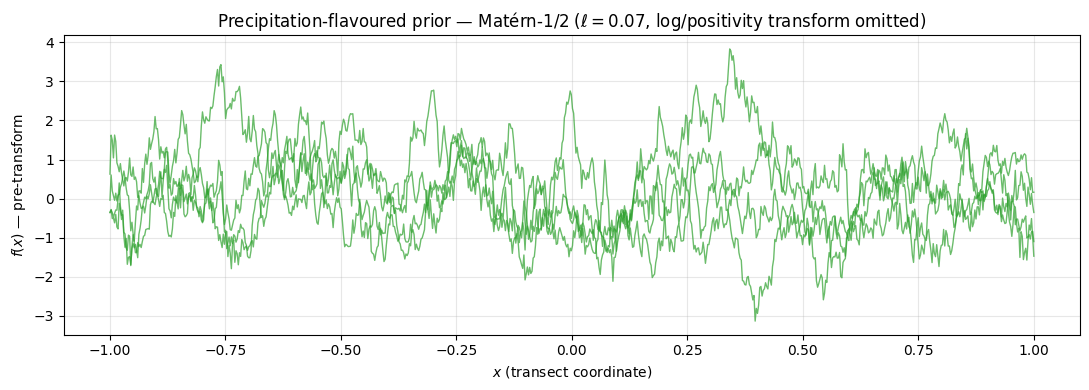

In [9]:
LENGTHSCALE_LAND = 0.07
M_LAND = 2048
xL = jnp.linspace(-1.0, 1.0, 800).reshape(-1, 1)
land_layer = make_layer(
    "Matérn-1/2", in_features=1, n_features=M_LAND, lengthscale=LENGTHSCALE_LAND
)
land_paths = gp_paths_from_layer(
    land_layer, xL, lengthscale=LENGTHSCALE_LAND, seed_omega=2, seed_beta=200, n_paths=4
)

fig, ax = plt.subplots(figsize=(11, 4))
for s in range(4):
    ax.plot(xL[:, 0], land_paths[s], color="C2", alpha=0.7, linewidth=1.0)
ax.set_xlabel("$x$ (transect coordinate)")
ax.set_ylabel("$f(x)$ — pre-transform")
ax.set_title(
    f"Precipitation-flavoured prior — Matérn-1/2 ($\\ell = {LENGTHSCALE_LAND}$, "
    "log/positivity transform omitted)"
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Atmosphere

| Variable | Kernel | Why | Refs |
|---|---|---|---|
| Temperature, pressure (synoptic) | Matérn-5/2 | quasi-geostrophic ⇒ at least two derivatives | [^daley1991][^gaspari1999] |
| Wind | bivariate Matérn / divergence-free | components share length scale; physical constraint | [^gneiting2010] |
| Trace gases (CO₂, CH₄) | Matérn-1/2 to 3/2 + non-Gaussian | plumes / sources are intermittent | [^ganesan2014] |

**Demo: a synoptic-temperature-flavoured 2D field.** A Matérn-5/2 prior with a relatively long lengthscale gives the broad, smooth highs and lows characteristic of synoptic-scale temperature anomaly maps.

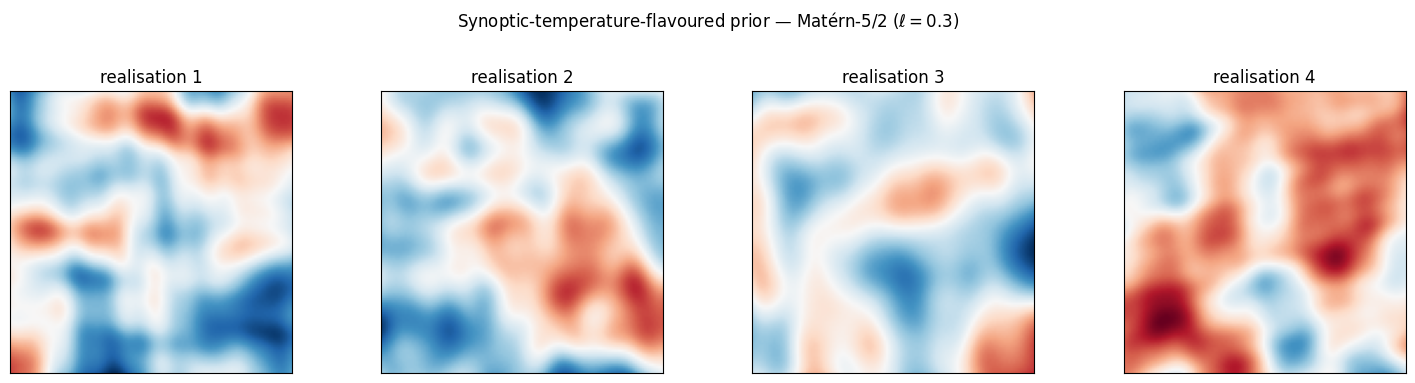

In [10]:
LENGTHSCALE_ATMOS = 0.30
M_ATMOS = 2048
n_grid_atmos = 120
xs_a = jnp.linspace(-1.0, 1.0, n_grid_atmos)
Xa, Ya = jnp.meshgrid(xs_a, xs_a, indexing="xy")
x2_atmos = jnp.stack([Xa.flatten(), Ya.flatten()], axis=-1)
atmos_layer = make_layer(
    "Matérn-5/2", in_features=2, n_features=M_ATMOS, lengthscale=LENGTHSCALE_ATMOS
)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, seed in zip(axes, [0, 1, 2, 3], strict=False):
    paths = gp_paths_from_layer(
        atmos_layer,
        x2_atmos,
        lengthscale=LENGTHSCALE_ATMOS,
        seed_omega=seed,
        seed_beta=300 + seed,
        n_paths=1,
    )
    field = np.asarray(paths[0]).reshape(n_grid_atmos, n_grid_atmos)
    vmax = float(np.abs(field).max())
    ax.imshow(
        field,
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
        origin="lower",
        extent=(-1, 1, -1, 1),
    )
    ax.set_title(f"realisation {seed + 1}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle(
    f"Synoptic-temperature-flavoured prior — Matérn-5/2 ($\\ell = {LENGTHSCALE_ATMOS}$)",
    y=1.05,
)
plt.tight_layout()
plt.show()

Long-wavelength dipoles and tripoles, smooth but not analytically so — exactly the qualitative content one expects in a 500 hPa temperature anomaly field at synoptic scale. A Matérn-1/2 prior would be wrong here; an RBF prior over-smooths the fronts.

**Wind speed — vector magnitude from independent Matérn components.** Wind has two components $(u, v)$, each well-modelled by a Matérn-3/2 prior with similar lengthscale [^gneiting2010]. The *speed* $\|u, v\| = \sqrt{u^2 + v^2}$ is positive and (when $u, v$ are zero-mean Gaussian) follows a Rayleigh-like distribution at each location — the classical empirical fit for surface-wind histograms. Drawing $u$ and $v$ independently from the same kernel, then taking the magnitude, gives a quick visual prior over wind-speed maps without ever sampling a non-Gaussian field directly.

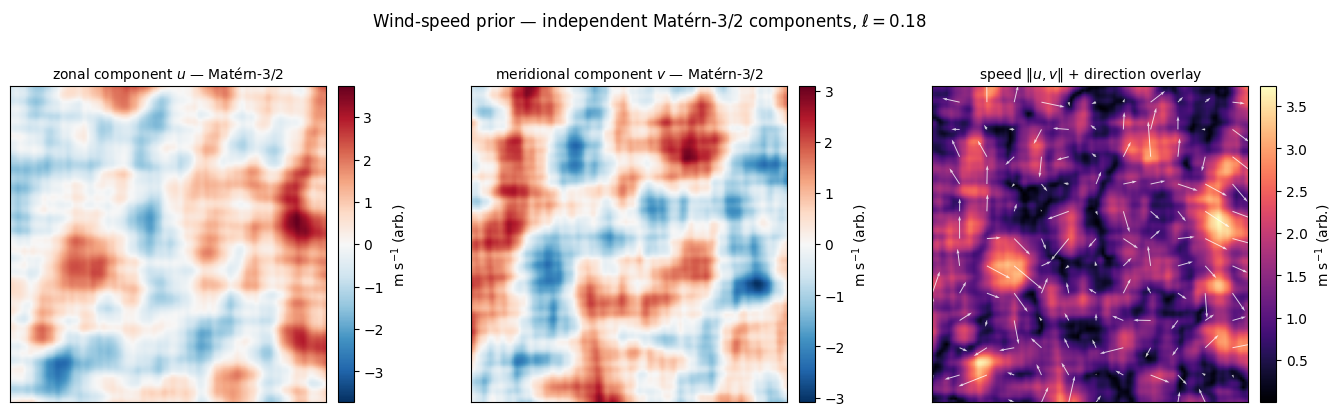

In [11]:
LENGTHSCALE_WIND = 0.18
M_WIND = 2048
n_grid_wind = 140
xs_w = jnp.linspace(-1.0, 1.0, n_grid_wind)
Xw, Yw = jnp.meshgrid(xs_w, xs_w, indexing="xy")
x2_wind = jnp.stack([Xw.flatten(), Yw.flatten()], axis=-1)

wind_layer = make_layer(
    "Matérn-3/2", in_features=2, n_features=M_WIND, lengthscale=LENGTHSCALE_WIND
)
u_paths = gp_paths_from_layer(
    wind_layer,
    x2_wind,
    lengthscale=LENGTHSCALE_WIND,
    seed_omega=21,
    seed_beta=521,
    n_paths=1,
)
v_paths = gp_paths_from_layer(
    wind_layer,
    x2_wind,
    lengthscale=LENGTHSCALE_WIND,
    seed_omega=22,
    seed_beta=522,
    n_paths=1,
)
u = np.asarray(u_paths[0]).reshape(n_grid_wind, n_grid_wind)
v = np.asarray(v_paths[0]).reshape(n_grid_wind, n_grid_wind)
speed = np.sqrt(u**2 + v**2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.0))

ax = axes[0]
vmax = float(np.abs(u).max())
im = ax.imshow(
    u, cmap="RdBu_r", vmin=-vmax, vmax=vmax, origin="lower", extent=(-1, 1, -1, 1)
)
ax.set_title("zonal component $u$ — Matérn-3/2", fontsize=10)
ax.set_xticks([])
ax.set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03, label="m s$^{-1}$ (arb.)")

ax = axes[1]
vmax = float(np.abs(v).max())
im = ax.imshow(
    v, cmap="RdBu_r", vmin=-vmax, vmax=vmax, origin="lower", extent=(-1, 1, -1, 1)
)
ax.set_title("meridional component $v$ — Matérn-3/2", fontsize=10)
ax.set_xticks([])
ax.set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03, label="m s$^{-1}$ (arb.)")

ax = axes[2]
im = ax.imshow(speed, cmap="magma", origin="lower", extent=(-1, 1, -1, 1))
# Sparse quiver overlay so the direction structure is also visible.
step = 12
xs_q = np.linspace(-1, 1, n_grid_wind)
ax.quiver(
    xs_q[::step],
    xs_q[::step],
    u[::step, ::step],
    v[::step, ::step],
    color="white",
    alpha=0.8,
    scale=None,
    width=0.003,
)
ax.set_title("speed $\\|u, v\\|$ + direction overlay", fontsize=10)
ax.set_xticks([])
ax.set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03, label="m s$^{-1}$ (arb.)")

plt.suptitle(
    f"Wind-speed prior — independent Matérn-3/2 components, $\\ell = {LENGTHSCALE_WIND}$",
    y=1.02,
)
plt.tight_layout()
plt.show()

The two component panels are zero-mean Gaussian, so they look like unsigned anomaly maps. The magnitude panel is positive everywhere and shows the **speed maxima at the boundaries between sign changes in either component** — the qualitative signature of jet-like and frontal wind structure. A more rigorous prior over wind would use a *bivariate* Matérn cross-covariance (Gneiting et al. JASA 2010 [^gneiting2010]) so that $u$ and $v$ share lengthscale and a physical correlation; the independent-components shortcut here is the cheapest visual prior that still respects the right marginals.

## Summary

- **Spectral kernels are priors over functions, parameterised by a spectral density.** Choose by reasoning about (a) regularity, (b) spectral tail, (c) stationarity. The decision table in §2 collapses these into a single look-up.
- **For Earth-system data, Matérn-$\nu$ is almost always the right family.** $\nu = 5/2$ for synoptic temperature / smooth land variables, $3/2$ for mesoscale ocean / kriging defaults, $1/2$ for turbulent / intermittent / heavy-tailed fields. RBF is rarely the right default [^stein1999].
- **Non-stationary structure needs a different machinery.** ArcCosine [^chosaul2009] is the simplest entry point; deep RFFs and spectral-mixture kernels [^wilsonadams2013] go further.
- **Use the prior as a sanity check before fitting.** The 2D fields above are what you should *expect* from your model before any data; if the prior samples don't look like plausible realisations of your domain, the kernel choice is wrong, no matter how good the marginal-likelihood number.

Where to next: with a kernel chosen, the [Random Fourier Features regression notebook](random_fourier_features.ipynb) shows how to do **inference** (MAP / SSGP / VSSGP) using exactly these spectral layers. The [Deep Random Feature Expansions notebook](deep_random_fourier_features.ipynb) covers the hierarchical / non-stationary extensions.

## References

[^chosaul2009]: Cho, Y., Saul, L. K. *Kernel Methods for Deep Learning*. NeurIPS 2009. — arc-cosine kernel and the relation to infinite-width ReLU networks.

[^stein1999]: Stein, M. L. *Interpolation of Spatial Data: Some Theory for Kriging*. Springer 1999. — canonical argument that Matérn beats RBF for geophysical fields.

[^williamsrasmussen2006]: Rasmussen, C. E., Williams, C. K. I. *Gaussian Processes for Machine Learning*. MIT Press 2006. — the standard ML-side GP textbook.

[^cressiewikle2011]: Cressie, N., Wikle, C. K. *Statistics for Spatio-Temporal Data*. Wiley 2011. — multilevel hierarchical models with Matérn priors for geophysical data.

[^wilsonadams2013]: Wilson, A. G., Adams, R. P. *Gaussian Process Kernels for Pattern Discovery and Extrapolation*. ICML 2013. — spectral-mixture kernels.

[^ubelmann2014]: Ubelmann, C., Klein, P., Fu, L.-L. *Dynamic interpolation of sea-surface height and potential applications for future high-resolution altimetry mapping*. Journal of Atmospheric and Oceanic Technology 31, 2014. — Matérn priors for SSH altimetry.

[^letraon2003]: Le Traon, P. Y., Faugère, Y., Hernandez, F., Dorandeu, J., Mertz, F., Ablain, M. *Can we merge GEOSAT follow-on with TOPEX/Poseidon and ERS-2 for an improved description of the ocean circulation?*. Journal of Atmospheric and Oceanic Technology 20, 2003. — DUACS multi-mission optimal interpolation.

[^banzon2016]: Banzon, V., Smith, T. M., Chin, T. M., Liu, C., Hankins, W. *A long-term record of blended satellite and in situ sea-surface temperature for climate monitoring, modeling and environmental studies*. Earth Syst. Sci. Data 8, 2016. — Reynolds OISST.

[^reul2020]: Reul, N., Grodsky, S. A., Arias, M., et al. *Sea surface salinity estimates from spaceborne L-band radiometers: An overview of the first decade of observation (2010–2019)*. Remote Sensing of Environment 242, 2020. — SMAP / SMOS / Aquarius.

[^doney2007]: Doney, S. C., Lima, I., Lindsay, K., Moore, J. K., Dutkiewicz, S., Friedrichs, M. A. M., Matear, R. J. *Marine biogeochemical modeling: Recent advances and future challenges*. Oceanography 20, 2007. — heavy-tailed ocean colour distributions.

[^hengl2018]: Hengl, T., Nussbaum, M., Wright, M. N., Heuvelink, G. B. M., Gräler, B. *Random forest as a generic framework for predictive modeling of spatial and spatio-temporal variables*. PeerJ 6, 2018. — land-surface variable mapping.

[^vereecken2008]: Vereecken, H., Huisman, J. A., Bogena, H., Vanderborght, J., Vrugt, J. A., Hopmans, J. W. *On the value of soil moisture measurements in vadose zone hydrology: A review*. Water Resources Research 44, 2008. — soil moisture geostatistics.

[^sun2018]: Sun, Q., Miao, C., Duan, Q., Ashouri, H., Sorooshian, S., Hsu, K.-L. *A review of global precipitation data sets: Data sources, estimation, and intercomparisons*. Reviews of Geophysics 56, 2018. — precipitation distributions and challenges.

[^gneiting2002]: Gneiting, T. *Nonseparable, stationary covariance functions for space–time data*. Journal of the American Statistical Association 97, 2002. — separable / nonseparable Matérn classes.

[^daley1991]: Daley, R. *Atmospheric Data Analysis*. Cambridge University Press 1991. — classical objective analysis with smooth correlation functions.

[^gaspari1999]: Gaspari, G., Cohn, S. E. *Construction of correlation functions in two and three dimensions*. Quarterly Journal of the Royal Meteorological Society 125, 1999. — compactly-supported correlation functions used in NWP DA.

[^gneiting2010]: Gneiting, T., Kleiber, W., Schlather, M. *Matérn cross-covariance functions for multivariate random fields*. Journal of the American Statistical Association 105, 2010. — multivariate / wind-vector Matérn.

[^ganesan2014]: Ganesan, A. L., Rigby, M., Zammit-Mangion, A., et al. *Characterization of uncertainties in atmospheric trace gas inversions using hierarchical Bayesian methods*. Atmos. Chem. Phys. 14, 2014. — hierarchical priors for atmospheric inversions.